In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


## Data Frame

In [7]:
housing_data = pd.read_csv("Housing.csv")
print(housing_data.head())


      price  area  bedrooms  ...  parking  prefarea furnishingstatus
0  13300000  7420         4  ...        2       yes        furnished
1  12250000  8960         4  ...        3        no        furnished
2  12250000  9960         3  ...        2       yes   semi-furnished
3  12215000  7500         4  ...        3       yes        furnished
4  11410000  7420         4  ...        2        no        furnished

[5 rows x 13 columns]


In [8]:
missing_values = housing_data.isnull().sum()
print(missing_values)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [9]:
categorical_colums = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
for column in categorical_colums:
  housing_data[column] = housing_data[column].map({'yes': 1, 'no': 0, 'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})


In [10]:
print(housing_data.head())

      price  area  bedrooms  ...  parking  prefarea  furnishingstatus
0  13300000  7420         4  ...        2         1                 2
1  12250000  8960         4  ...        3         0                 2
2  12250000  9960         3  ...        2         1                 1
3  12215000  7500         4  ...        3         1                 2
4  11410000  7420         4  ...        2         0                 2

[5 rows x 13 columns]


In [11]:
import pandas as pd

pd.set_option('display.max_columns', None)

print(housing_data.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 2  
1                 2  
2                 1  
3                 2  
4                 2  


## visualizing the data/ relationship between targeted variables and independent variables


Text(0.5, 1.0, 'Stories vs Price')

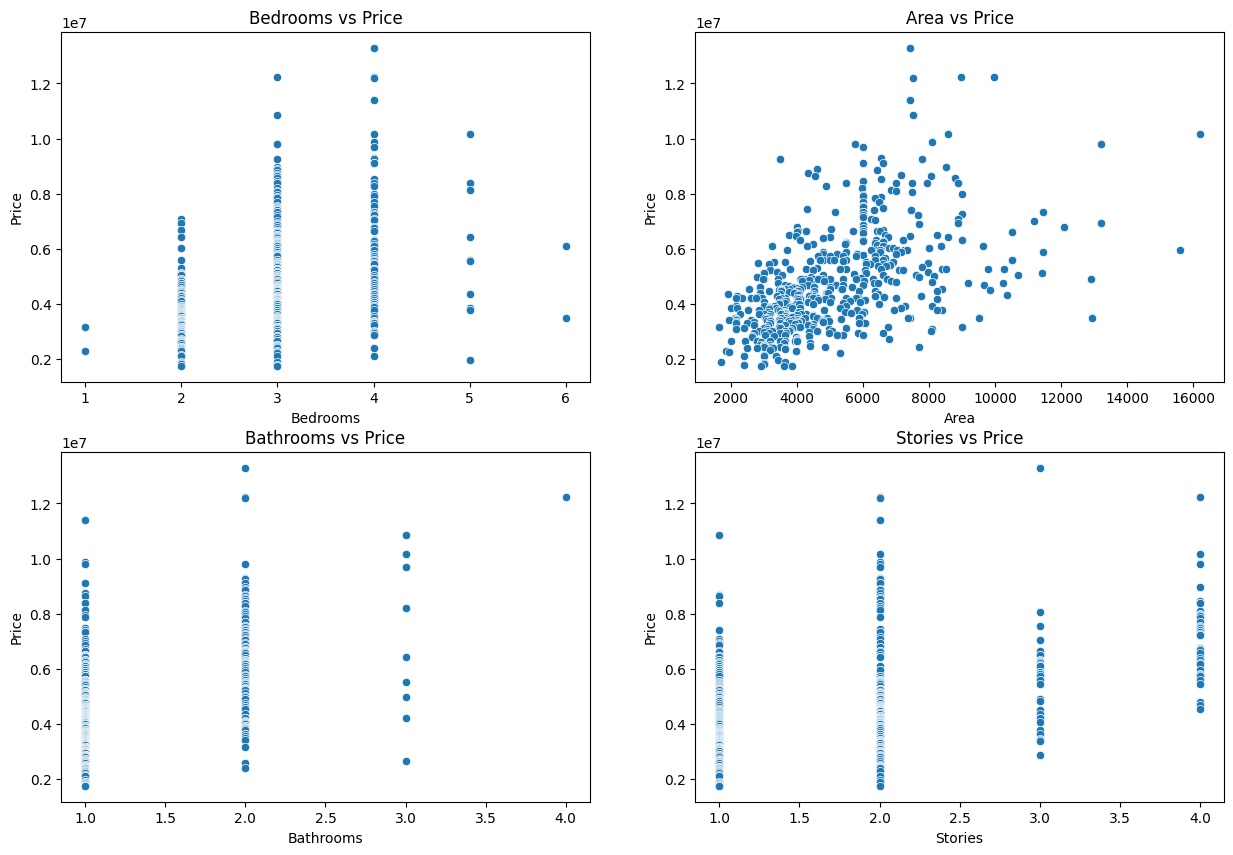

In [14]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,2)
sns.scatterplot(x='area' ,y='price', data=housing_data)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')

plt.subplot(2,2,1)
sns.scatterplot(x='bedrooms' ,y='price', data=housing_data)
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.title('Bedrooms vs Price')

plt.subplot(2,2,3)
sns.scatterplot(x='bathrooms' ,y='price', data=housing_data)
plt.xlabel('Bathrooms')
plt.ylabel('Price')
plt.title('Bathrooms vs Price')

plt.subplot(2,2,4)
sns.scatterplot(x='stories' ,y='price', data=housing_data)
plt.xlabel('Stories')
plt.ylabel('Price')
plt.title('Stories vs Price')

## Spliting the data into traning and testing

In [15]:
X = housing_data.drop('price', axis=1)
y = housing_data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Applying Algorithm

In [16]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = lm.predict(X_test) # testing the model

## Evaluation

- MSE- Mean Square Errored
- R^2 (R-Squarred) - How well model explain the data


In [18]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 1771751116594.0352
R-squared: 0.6494754192267803


## Random Forest algorithm

In [19]:
#from sklearn.ensemble import RandomForestRegressor

In [20]:
#rm = RandomForestRegressor(n_estimators=100, random_state=42)
#rm.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [21]:
#rm_y_pred = rm.predict(X_test)

In [22]:
#mse_rm = mean_squared_error(y_test, rm_y_pred)
#r2_rm = r2_score(y_test, rm_y_pred)

#print("Mean Squared Error:", mse_rm)
#print("R-squared:", r2_rm)

Mean Squared Error: 1956925181711.5183
R-squared: 0.612840442148196


## House Price Prediction

In [23]:
new_house = pd.DataFrame({
    'area': [1500],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'mainroad': [1],
    'guestroom': [1],
    'basement': [1],
    'hotwaterheating': [1],
    'airconditioning': [1],
    'parking': [2],
    'prefarea': [1],
    'furnishingstatus': [2]
})

#predict price
predicted_price = lm.predict(new_house)
print("Predicted Price:", predicted_price[0])

Predicted Price: 7437237.881013153
